<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_14_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

In [52]:
veri = pd.read_csv("/content/otel_rezervasyon.csv")

In [53]:
veri.head()

,rezervasyon_no,sezon,iade_kosulu,kac_gun_once,gece_sayisi,oda_fiyati,onceki_iptal_sayisi,iptal_edildi
0,9001,Yaz,İade Edilebilir,111,7,3070.0,0,Evet
1,9002,Sonbahar,İade Edilebilir,219,2,2280.0,0,Evet
2,9003,Yaz,İade Edilebilir,163,2,3980.0,4,Evet
3,9004,İlkbahar,İade Edilemez,94,4,970.0,0,Hayır
4,9005,İlkbahar,İade Edilebilir,122,1,2410.0,0,Hayır


In [54]:
veri.shape

(805, 8)

In [55]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805 entries, 0 to 804
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   rezervasyon_no       805 non-null    int64  
 1   sezon                805 non-null    object 
 2   iade_kosulu          805 non-null    object 
 3   kac_gun_once         805 non-null    int64  
 4   gece_sayisi          805 non-null    int64  
 5   oda_fiyati           786 non-null    float64
 6   onceki_iptal_sayisi  805 non-null    int64  
 7   iptal_edildi         805 non-null    object 
dtypes: float64(1), int64(4), object(3)
memory usage: 50.4+ KB


In [56]:
veri.isnull().sum() # 19 adet "oda_fiyati" sütununda boş veri mevcut.

,0
rezervasyon_no,0
sezon,0
iade_kosulu,0
kac_gun_once,0
gece_sayisi,0
oda_fiyati,19
onceki_iptal_sayisi,0
iptal_edildi,0


In [57]:
veri.duplicated().sum()

np.int64(5)

In [58]:
veri[veri.duplicated(keep=False)] # 5 adet tekrar eden satır varmış.

,rezervasyon_no,sezon,iade_kosulu,kac_gun_once,gece_sayisi,oda_fiyati,onceki_iptal_sayisi,iptal_edildi
40,9041,İlkbahar,İade Edilebilir,33,1,2580.0,0,Hayır
41,9041,İlkbahar,İade Edilebilir,33,1,2580.0,0,Hayır
221,9221,Sonbahar,İade Edilebilir,8,5,NaN,0,Hayır
222,9221,Sonbahar,İade Edilebilir,8,5,NaN,0,Hayır
507,9506,Yaz,İade Edilemez,84,4,3080.0,1,Hayır
508,9506,Yaz,İade Edilemez,84,4,3080.0,1,Hayır
621,9619,Sonbahar,İade Edilebilir,6,4,3670.0,0,Hayır
622,9619,Sonbahar,İade Edilebilir,6,4,3670.0,0,Hayır
737,9734,Kış,İade Edilebilir,23,3,1630.0,0,Hayır
738,9734,Kış,İade Edilebilir,23,3,1630.0,0,Hayır


In [59]:
veri.describe()

,rezervasyon_no,kac_gun_once,gece_sayisi,oda_fiyati,onceki_iptal_sayisi
count,805.000000,805.000000,805.00000,786.000000,805.000000
mean,9400.647205,47.588820,3.63354,2763.651399,1.145342
std,231.258018,50.872278,2.57690,1024.679674,1.399180
min,9001.000000,0.000000,1.00000,800.000000,0.000000
25%,9201.000000,11.000000,2.00000,1982.500000,0.000000
50%,9401.000000,31.000000,3.00000,2655.000000,1.000000
75%,9601.000000,67.000000,5.00000,3497.500000,2.000000
max,9800.000000,300.000000,14.00000,5600.000000,5.000000


In [60]:
# VERİYİ TEMİZLEME (Tekrar edenleri sil ve eksik verileri doldur.)
veri = veri.drop_duplicates() # tekrar eden satırları sildik.
veri.shape


(800, 8)

In [61]:
ortanca_fiyat = veri["oda_fiyati"].median()
ortanca_fiyat

2655.0

In [62]:
veri["oda_fiyati"] = veri["oda_fiyati"].fillna(ortanca_fiyat) # boş verilerimizi doldurduk.
veri

,rezervasyon_no,sezon,iade_kosulu,kac_gun_once,gece_sayisi,oda_fiyati,onceki_iptal_sayisi,iptal_edildi
0,9001,Yaz,İade Edilebilir,111,7,3070.0,0,Evet
1,9002,Sonbahar,İade Edilebilir,219,2,2280.0,0,Evet
2,9003,Yaz,İade Edilebilir,163,2,3980.0,4,Evet
3,9004,İlkbahar,İade Edilemez,94,4,970.0,0,Hayır
4,9005,İlkbahar,İade Edilebilir,122,1,2410.0,0,Hayır
...,...,...,...,...,...,...,...,...
800,9796,Yaz,İade Edilebilir,124,4,3490.0,0,Evet
801,9797,Yaz,İade Edilebilir,142,6,3730.0,0,Evet
802,9798,Yaz,İade Edilemez,9,4,3930.0,2,Hayır
803,9799,Yaz,İade Edilemez,80,4,2650.0,0,Hayır


In [63]:
veri.isnull().sum()

,0
rezervasyon_no,0
sezon,0
iade_kosulu,0
kac_gun_once,0
gece_sayisi,0
oda_fiyati,0
onceki_iptal_sayisi,0
iptal_edildi,0


In [64]:
# VERİ GÖRSELLEŞTİRME
# Rezervasyon iptal evet hayır kaç adet bar grafiği. (rezervasyon iptal edildi mi?)

veri['iptal_edildi'].value_counts()


,count
iptal_edildi,
Hayır,575
Evet,225


In [65]:
veri['iptal_edildi'].value_counts(normalize=True).round(2) # round yuvarlama virgülden sonra kaç adet sayı gösterilsin.


,proportion
iptal_edildi,
Hayır,0.72
Evet,0.28


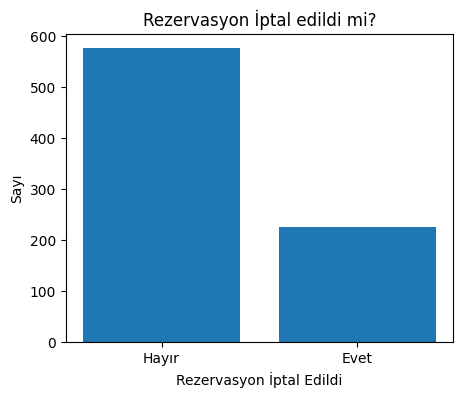

In [66]:
plt.figure(figsize=(5,4))
plt.bar(["Hayır", "Evet"], veri['iptal_edildi'].value_counts()[["Hayır", "Evet"]])
plt.title( "Rezervasyon İptal edildi mi?")
plt.xlabel("Rezervasyon İptal Edildi")
plt.ylabel("Sayı")
plt.show()
#

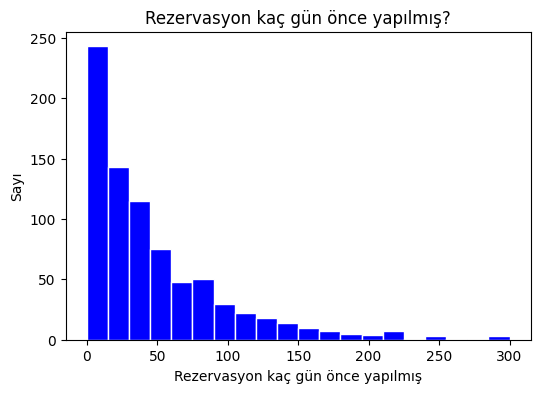

In [67]:
# Histogram kaç gün önceden rezervasyon yapılmış. plt.hist

plt.figure(figsize=(6,4))
plt.hist(veri['kac_gun_once'], bins=20, color="b",edgecolor="white")
plt.title("Rezervasyon kaç gün önce yapılmış?")
plt.xlabel("Rezervasyon kaç gün önce yapılmış")
plt.ylabel("Sayı")
plt.show()
#

In [68]:
# hangi sezonda daha çok iptal var?
sezon_sayisi = veri.groupby("sezon")["iptal_edildi"].value_counts()
sezon_sayisi

sezon     iptal_edildi
Kış       Hayır           125
          Evet             19
Sonbahar  Hayır           120
          Evet             46
Yaz       Hayır           198
          Evet            103
İlkbahar  Hayır           132
          Evet             57
Name: count, dtype: int64

In [69]:
pd.crosstab(veri["sezon"], veri["iptal_edildi"]) # 2 sütun arasında çapraz ilişkiyi tablolaştırır.

iptal_edildi,Evet,Hayır
sezon,,
Kış,19,125
Sonbahar,46,120
Yaz,103,198
İlkbahar,57,132


In [70]:
# Metinsel ifadeleri sayısal ifadelere çevirmek.

veri = pd.get_dummies(veri, columns=["sezon","iade_kosulu"], drop_first=True, dtype=int)
veri.head()
#


,rezervasyon_no,kac_gun_once,gece_sayisi,oda_fiyati,onceki_iptal_sayisi,iptal_edildi,sezon_Sonbahar,sezon_Yaz,sezon_İlkbahar,iade_kosulu_İade Edilemez
0,9001,111,7,3070.0,0,Evet,0,1,0,0
1,9002,219,2,2280.0,0,Evet,1,0,0,0
2,9003,163,2,3980.0,4,Evet,0,1,0,0
3,9004,94,4,970.0,0,Hayır,0,0,1,1
4,9005,122,1,2410.0,0,Hayır,0,0,1,0


In [73]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 0 to 804
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   rezervasyon_no             800 non-null    int64  
 1   kac_gun_once               800 non-null    int64  
 2   gece_sayisi                800 non-null    int64  
 3   oda_fiyati                 800 non-null    float64
 4   onceki_iptal_sayisi        800 non-null    int64  
 5   iptal_edildi               800 non-null    object 
 6   sezon_Sonbahar             800 non-null    int64  
 7   sezon_Yaz                  800 non-null    int64  
 8   sezon_İlkbahar             800 non-null    int64  
 9   iade_kosulu_İade Edilemez  800 non-null    int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 68.8+ KB


In [75]:
# X ve y olarak ayırma

X = veri.drop(columns=["rezervasyon_no","iptal_edildi"])
y = veri["iptal_edildi"]

In [77]:
X.head()

,kac_gun_once,gece_sayisi,oda_fiyati,onceki_iptal_sayisi,sezon_Sonbahar,sezon_Yaz,sezon_İlkbahar,iade_kosulu_İade Edilemez
0,111,7,3070.0,0,0,1,0,0
1,219,2,2280.0,0,1,0,0,0
2,163,2,3980.0,4,0,1,0,0
3,94,4,970.0,0,0,0,1,1
4,122,1,2410.0,0,0,0,1,0


In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [81]:
X_train.shape

(640, 8)

In [83]:
X_test.shape

(160, 8)

In [85]:
# Sınırsız Ağaç (Ezber yapan ağaç)
agac_sinirsiz = DecisionTreeClassifier()
agac_sinirsiz.fit(X_train, y_train)

DecisionTreeClassifier()

In [87]:
accuracy_score(y_train, agac_sinirsiz.predict(X_train)) # Eğitim Doğruluğu

1.0

In [89]:
accuracy_score(y_test, agac_sinirsiz.predict(X_test)) # Test Doğruluğu
#

0.85

In [92]:
print("Ağaç derinliği:", agac_sinirsiz.get_depth())
print("Yaprak sayısı:", agac_sinirsiz.get_n_leaves())
#

Ağaç derinliği: 13
Yaprak sayısı: 80


In [94]:
#Budanmış Ağaç ve Kural
agac = DecisionTreeClassifier(max_depth=4, min_impurity_decrease=0.005, random_state=42)
agac.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_impurity_decrease=0.005,
                       random_state=42)

In [96]:
agac_tahmin = agac.predict(X_test)

In [98]:
print("Eğitim Doğruluk:", accuracy_score(y_train, agac.predict(X_train)))
print("Test Doğruluk:", accuracy_score(y_test, agac_tahmin))
print("Ağaç Derinliği:", agac.get_depth())
print("Yaprak Sayısı:", agac.get_n_leaves())
#

Eğitim Doğruluk: 0.940625
Test Doğruluk: 0.93125
Ağaç Derinliği: 4
Yaprak Sayısı: 6


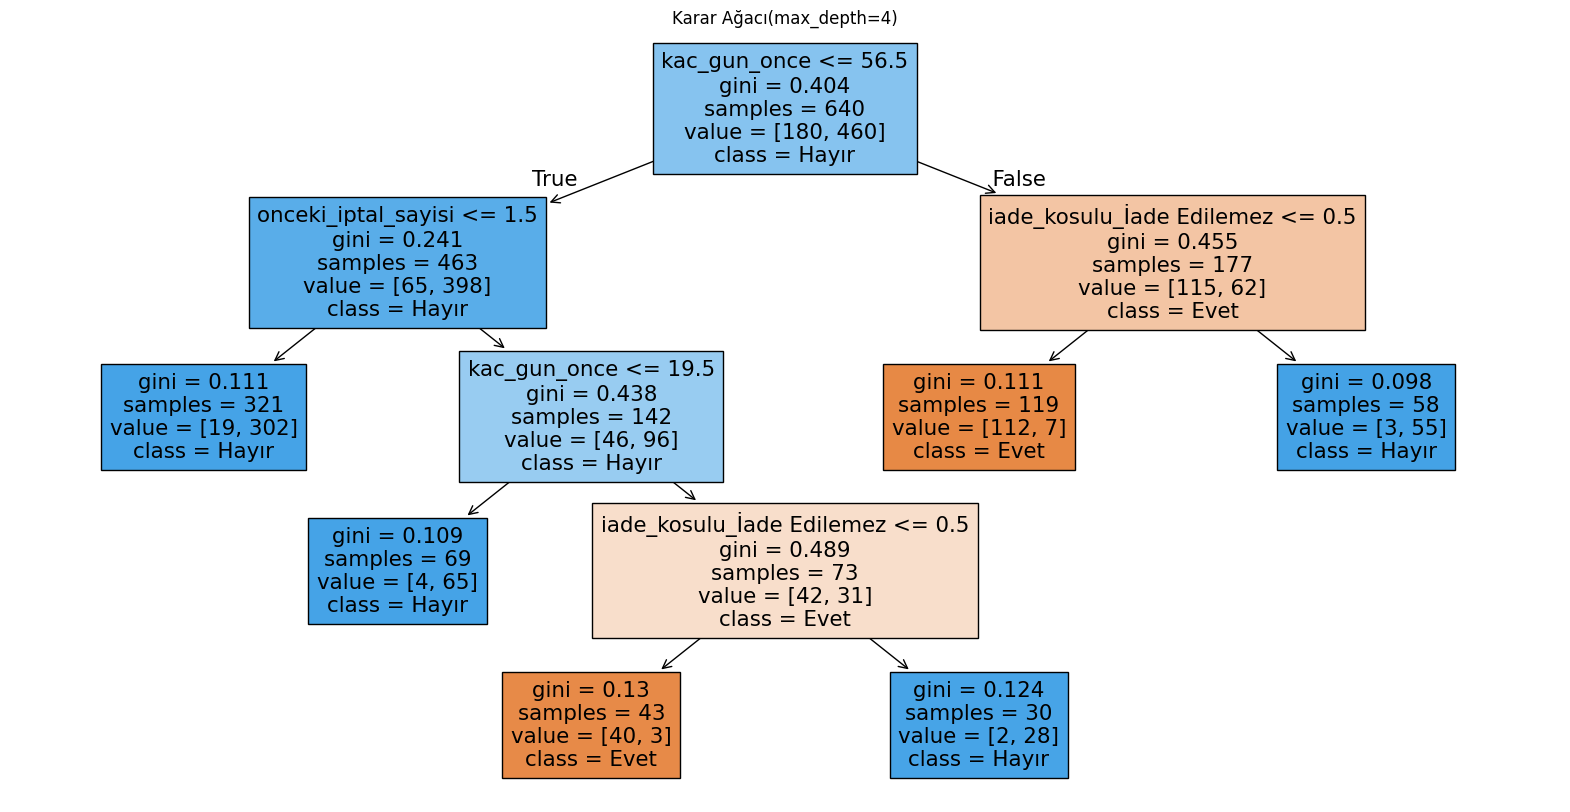

In [100]:
plt.figure(figsize=(20,10))
plot_tree(agac, feature_names=list(X.columns), class_names=["Evet", "Hayır"], filled=True)
plt.title("Karar Ağacı(max_depth=4)")
plt.show()

In [101]:
onem = pd.Series(agac.feature_importances_, index=X.columns).sort_values(ascending=False) #hangi sütun ne kadar önemli bilgisini alıyoruz.
onem

,0
iade_kosulu_İade Edilemez,0.470175
kac_gun_once,0.456132
onceki_iptal_sayisi,0.073694
gece_sayisi,0.000000
oda_fiyati,0.000000
sezon_Sonbahar,0.000000
sezon_Yaz,0.000000
sezon_İlkbahar,0.000000
